In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
import mod as m 

In [ ]:
# USER INPUT: data information
date = '04-17-26'
path = f'Data/HighPressureTesting-{date}/'
p = 655


ps = [363, p]

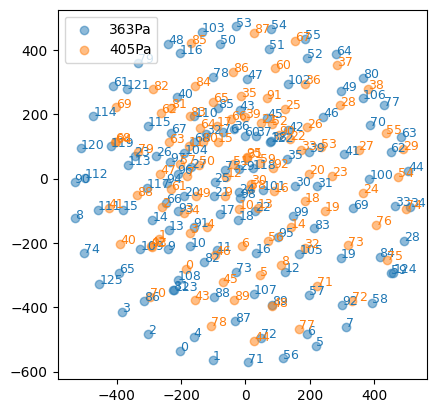

In [ ]:
fig, ax = plt.subplots()

for i, p in enumerate( ps ): 
    arr = np.loadtxt(path+f"WithRing-{p}Pa.txt")
    ax.scatter(arr[:,0], arr[:,1], color=f'C{i}', alpha=0.5, label=f'{p}Pa')    
    for j, (xi, yi) in enumerate(zip(arr[:,0], arr[:,1])):
        ax.text(xi, yi, str(j), fontsize=9, color=f'C{i}')

ax.set_aspect('equal')
ax.legend()    

In [ ]:
def linear_transformation(refs, arr, indr, inda):
    x_ref, y_ref = refs[indr,0], refs[indr,1]
    x_arr, y_arr = arr[inda,0], arr[inda,1]

    dx = x_ref - x_arr
    dy = y_ref - y_arr

    return arr[:,0] + dx, arr[:,1] + dy

In [ ]:
def align_points_2d(refs, arr):
    c_ref = refs.mean(axis=0)
    c_arr = arr.mean(axis=0)

    X = refs - c_ref
    Y = arr - c_arr

    H = Y.T @ X
    U, S, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T

    if np.linalg.det(R) < 0:
        Vt[1, :] *= -1
        R = Vt.T @ U.T

    rotated = (R @ arr.T).T 

    return rotated, R


### Select at least three points for reference for the alignment

In [40]:
arr = np.loadtxt(path+f"WithRing-{p}Pa.txt")
ref = np.loadtxt(path+f"WithRing-363Pa.txt")


# 1005
ind_arr = [54, 85, 53] ## USER INPUT: select index of points 
arr_r = np.vstack([arr[ind_arr,0], arr[ind_arr,1]]).T 

# reference, 363
ind_ref =[7, 8, 54] ## USER INPUT: select index of points 
ref_r = np.vstack([ref[ind_ref,0], ref[ind_ref,1]]).T

### Rotaton 

In [41]:
rotate, R = align_points_2d(ref_r, arr_r)

arr_s = np.vstack([arr[:,0], arr[:,1]]).T

arr_new = (R @ arr_s.T).T
arr_new.shape

(128, 2)

### Translation

In [42]:

x, y = linear_transformation(ref, arr_new, ind_ref[0], ind_arr[0])

### Confirm result

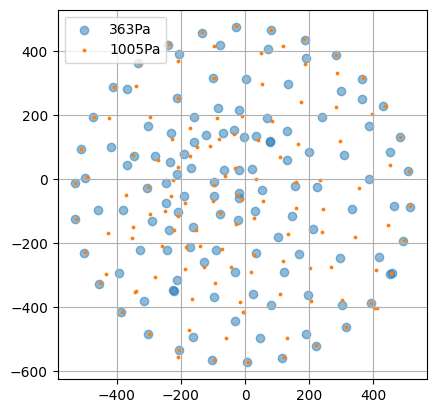

In [43]:
fig, ax = plt.subplots()

ax.scatter(ref[:,0], ref[:,1], color=f'C0', alpha=0.5, label=f'363Pa')
ax.scatter(x, y, color=f'C1', s=3, label=f'1005Pa')    

# for j, (xi, yi) in enumerate(zip(ref[:,0], ref[:,1])):
#     ax.text(xi, yi, str(j), fontsize=9, color=f'C0')
# for j, (xj, yj) in enumerate(zip(x, y)):
#     ax.text(xj, yj, str(j), fontsize=9, color=f'C1')
ax.grid()
ax.set_aspect('equal')
ax.legend()    

### Save file

In [44]:
filename = f"{p}Pa.txt"
m.write_txt_from_arrays("WithRing-"+filename, x, y, arr[:,2], date)
